In [ ]:
df = pd.read_csv('/london_merged.csv')

# Print the shape and column profiles
print(f"Dataset Dimensions: {df.shape}")
print("-" * 50)
df.info()

Dataset Dimensions: (17414, 10)
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   timestamp     17414 non-null  object 
 1   cnt           17414 non-null  int64  
 2   t1            17414 non-null  float64
 3   t2            17414 non-null  float64
 4   hum           17414 non-null  float64
 5   wind_speed    17414 non-null  float64
 6   weather_code  17414 non-null  float64
 7   is_holiday    17414 non-null  float64
 8   is_weekend    17414 non-null  float64
 9   season        17414 non-null  float64
dtypes: float64(8), int64(1), object(1)
memory usage: 1.3+ MB


In [ ]:
# Convert text timestamp column into an active datetime object
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Re-verify the data type shift
print(df['timestamp'].dtype)

datetime64[ns]


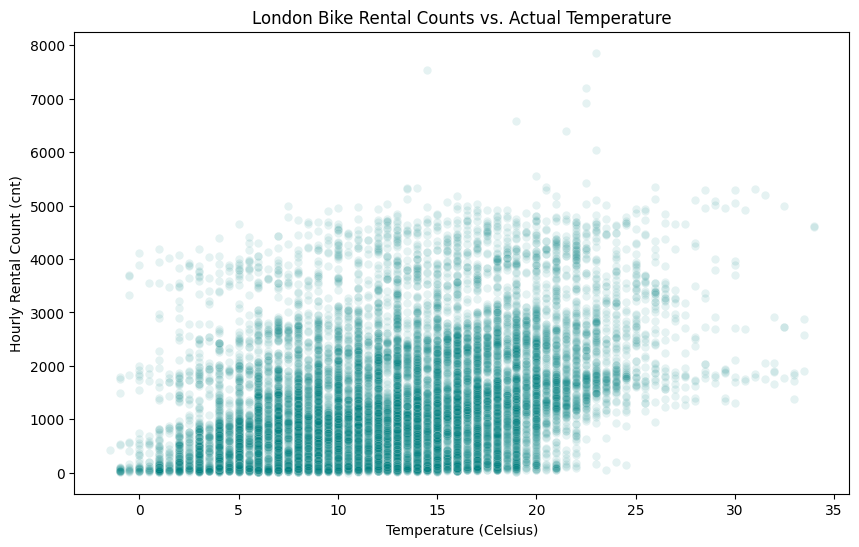

In [ ]:
# Generate a scatter plot to map temperature against rental counts
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='t1', y='cnt', alpha=0.1, color='teal')
plt.title('London Bike Rental Counts vs. Actual Temperature')
plt.xlabel('Temperature (Celsius)')
plt.ylabel('Hourly Rental Count (cnt)')
plt.show()

In [ ]:
# 1. Extract base chronological attributes from the datetime object
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

# 2. Engineer a custom high-impact business feature: is_rush_hour
# London weekday commuter peaks: Morning (7-9 AM) and Evening (4-6 PM / 16-18)
df['is_rush_hour'] = np.where(
    (df['is_weekend'] == 0) & (df['is_holiday'] == 0) &
    ((df['hour'].between(7, 9)) | (df['hour'].between(16, 18))),
    1, 0
)

# 3. Check your newly engineered data architecture
df[['timestamp', 'hour', 'day_of_week', 'is_rush_hour', 'cnt']].head(10)

,timestamp,hour,day_of_week,is_rush_hour,cnt
0,2015-01-04 00:00:00,0,6,0,182
1,2015-01-04 01:00:00,1,6,0,138
2,2015-01-04 02:00:00,2,6,0,134
3,2015-01-04 03:00:00,3,6,0,72
4,2015-01-04 04:00:00,4,6,0,47
5,2015-01-04 05:00:00,5,6,0,46
6,2015-01-04 06:00:00,6,6,0,51
7,2015-01-04 07:00:00,7,6,0,75
8,2015-01-04 08:00:00,8,6,0,131
9,2015-01-04 09:00:00,9,6,0,301


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Separate features (X) from the target label (y)
# We drop timestamp because models can't read datetime data directly
X = df.drop(columns=['timestamp', 'cnt'])
y = df['cnt']

# 2. Split data: 80% for training the model, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Features Matrix Shape: {X_train.shape}")
print(f"Testing Features Matrix Shape: {X_test.shape}")
print("-" * 50)

# 3. Initialize the model and train it
# n_jobs=-1 tells Colab to use all available CPU cores to speed up processing
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
print("Training the Random Forest Regressor... (This may take 10-20 seconds)")
model.fit(X_train, y_train)

# 4. Predict vehicle demand using the unseen test data
y_pred = model.predict(X_test)

# 5. Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n🚀 Model Training Complete! Here are your performance metrics:")
print(f"Mean Absolute Error (MAE): {mae:.2f} bikes")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} bikes")
print(f"R-squared (R2) Score: {r2:.4f}")

Training Features Matrix Shape: (13931, 12)
Testing Features Matrix Shape: (3483, 12)
--------------------------------------------------
Training the Random Forest Regressor... (This may take 10-20 seconds)

🚀 Model Training Complete! Here are your performance metrics:
Mean Absolute Error (MAE): 123.12 bikes
Root Mean Squared Error (RMSE): 228.60 bikes
R-squared (R2) Score: 0.9564


/tmp/ipykernel_4091/1635275398.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='mako')


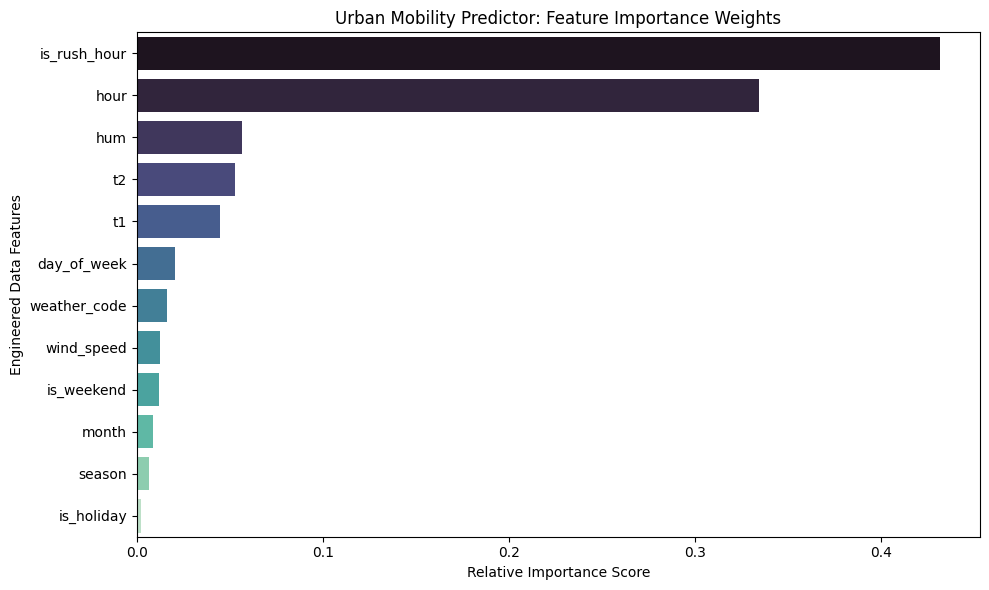

         Feature  Importance
11  is_rush_hour    0.431718
8           hour    0.334490
2            hum    0.056706
1             t2    0.052861
0             t1    0.044953
9    day_of_week    0.020491
4   weather_code    0.016081
3     wind_speed    0.012747
6     is_weekend    0.012117
10         month    0.008662
7         season    0.006668
5     is_holiday    0.002507


In [9]:
# Extract feature importances from the trained Random Forest model
importances = model.feature_importances_
feature_names = X.columns

# Organize into a clean, sorted DataFrame
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the Feature Importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='mako')
plt.title('Urban Mobility Predictor: Feature Importance Weights')
plt.xlabel('Relative Importance Score')
plt.ylabel('Engineered Data Features')
plt.tight_layout()
plt.show()

# Print the exact weights matrix
print(feature_imp_df)